Filter out pune data

In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv("Zomato_Data.csv")  # Replace with actual file path

In [2]:
df.dtypes

ID                              object
Delivery_person_ID              object
Delivery_person_Age            float64
Delivery_person_Ratings        float64
Restaurant_latitude            float64
Restaurant_longitude           float64
Delivery_location_latitude     float64
Delivery_location_longitude    float64
Order_Date                      object
Time_Orderd                     object
Time_Order_picked               object
Weather_conditions              object
Road_traffic_density            object
Vehicle_condition                int64
Type_of_order                   object
Type_of_vehicle                 object
multiple_deliveries            float64
Festival                        object
City                            object
Time_taken (min)                 int64
dtype: object

In [3]:
# Filter for Pune City (Delivery Person ID starts with "PUNERES")
df_pune = df[df["Delivery_person_ID"].str.startswith("PUNERES")]

# Select important features and rename multiple_deliveries to order_freq
df_pune = df_pune[[
    "ID", "Delivery_person_ID", "Restaurant_latitude", "Restaurant_longitude",
    "Delivery_location_latitude", "Delivery_location_longitude",
     "Road_traffic_density", "multiple_deliveries", "Time_taken (min)"
]].rename(columns={"multiple_deliveries": "order_freq"})

In [4]:
df_pune.isnull().sum()

ID                              0
Delivery_person_ID              0
Restaurant_latitude             0
Restaurant_longitude            0
Delivery_location_latitude      0
Delivery_location_longitude     0
Road_traffic_density           44
order_freq                     71
Time_taken (min)                0
dtype: int64

## Cleaning

In [5]:
# Fill missing values (if any) with appropriate values
df_pune["Road_traffic_density"].fillna("Medium", inplace=True)  # Default traffic density
df_pune["order_freq"].fillna(0, inplace=True)  # Fill missing order_freq with 0

C:\Users\HP\AppData\Local\Temp\ipykernel_28376\4191464450.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_pune["Road_traffic_density"].fillna("Medium", inplace=True)  # Default traffic density
C:\Users\HP\AppData\Local\Temp\ipykernel_28376\4191464450.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values

In [6]:
df_pune.columns

Index(['ID', 'Delivery_person_ID', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Road_traffic_density', 'order_freq',
       'Time_taken (min)'],
      dtype='object')

In [7]:
# Increase order frequency by +1
df_pune["order_freq"] += 1

In [8]:
# Save processed dataset
df_pune.to_csv("pune_filtered_data.csv", index=False)

# Show the first few rows
df_pune[0:5]

,ID,Delivery_person_ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,order_freq,Time_taken (min)
2,0x2784,PUNERES13DEL03,18.562450,73.916619,18.652450,74.006619,Medium,2.0,21
7,0x689b,PUNERES20DEL01,18.592718,73.773572,18.702718,73.883572,Jam,2.0,40
10,0x36b8,PUNERES19DEL02,18.563934,73.915367,18.643935,73.995367,Jam,3.0,36
19,0x3c5e,PUNERES04DEL01,18.514210,73.838429,18.624210,73.948429,Low,1.0,12
25,0x30c8,PUNERES19DEL02,18.563934,73.915367,18.693935,74.045367,Low,2.0,30


In [9]:
df_pune['order_freq'] = df_pune['order_freq'].astype(int)

In [10]:
df_pune['order_freq'].value_counts()

order_freq
2    1932
1    1045
3     131
4      24
Name: count, dtype: int64

In [11]:
df_pune['Road_traffic_density'].value_counts()

Road_traffic_density
Low       1061
Jam        974
Medium     789
High       308
Name: count, dtype: int64

Restaurant locations → candidate dark store locations

Delivery locations → customer demand points

order_freq → customer demand weight

Road_traffic_density + Weather_conditions → delivery friction

Time_taken (min) → real-world cost

In [12]:
df = df_pune

In [13]:
df['Restaurant_latitude'] = df['Restaurant_latitude'].abs()
df['Restaurant_longitude'] = df['Restaurant_longitude'].abs()

In [14]:
# Traffic weights
traffic_weights = {
    "Low": 1.0,
    "Medium": 1.3,
    "High": 1.6,
    "Jam": 2.0
}

df["traffic_weight"] = df["Road_traffic_density"].map(traffic_weights)

In [15]:
import numpy as np

def haversine(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in KM
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    return R * c

df["distance_km"] = haversine(
    df["Restaurant_latitude"],
    df["Restaurant_longitude"],
    df["Delivery_location_latitude"],
    df["Delivery_location_longitude"]
)


In [16]:
df["delivery_cost"] = (
    df["distance_km"]
    * df["traffic_weight"]
    * df["order_freq"]
)

In [17]:
df.head()

,ID,Delivery_person_ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,order_freq,Time_taken (min),traffic_weight,distance_km,delivery_cost
2,0x2784,PUNERES13DEL03,18.562450,73.916619,18.652450,74.006619,Medium,2,21,1.3,13.787860,35.848437
7,0x689b,PUNERES20DEL01,18.592718,73.773572,18.702718,73.883572,Jam,2,40,2.0,16.849940,67.399760
10,0x36b8,PUNERES19DEL02,18.563934,73.915367,18.643935,73.995367,Jam,3,36,2.0,12.256076,73.536459
19,0x3c5e,PUNERES04DEL01,18.514210,73.838429,18.624210,73.948429,Low,1,12,1.0,16.853619,16.853619
25,0x30c8,PUNERES19DEL02,18.563934,73.915367,18.693935,74.045367,Low,2,30,1.0,19.914687,39.829374


In [18]:
df[["Restaurant_latitude", "Restaurant_longitude"]].drop_duplicates().shape[0]

20

In [19]:
df["store_id"] = (
    df["Restaurant_latitude"].round(6).astype(str)
    + "_"
    + df["Restaurant_longitude"].round(6).astype(str)
)

In [20]:
df['store_id'].nunique()

20

In [21]:
store_metrics = (
    df.groupby("store_id")  # Restaurant_ID 
    .agg(
        total_orders=("order_freq", "sum"),
        avg_distance_km=("distance_km", "mean"),
        avg_delivery_time=("Time_taken (min)", "mean"),
        total_delivery_cost=("delivery_cost", "sum"),
        avg_traffic_weight=("traffic_weight", "mean"),
        delivery_count=("distance_km", "count")
    )
    .reset_index()
)


In [22]:
store_metrics

,store_id,total_orders,avg_distance_km,avg_delivery_time,total_delivery_cost,avg_traffic_weight,delivery_count
0,18.51421_73.838429,248,9.610151,25.884354,3723.096668,1.473469,147
1,18.516216_73.842527,276,9.598458,27.380645,4301.935605,1.482581,155
2,18.520016_73.830547,266,10.263443,27.910959,4337.098859,1.481507,146
3,18.530963_73.828972,279,9.659084,26.043478,4090.624966,1.421739,161
4,18.533811_73.899315,285,9.684517,26.086420,4336.342018,1.420988,162
5,18.53408_73.89852,290,9.801867,26.271084,4403.921417,1.460843,166
6,18.536562_73.896485,273,9.350822,28.116129,4161.046374,1.504516,155
7,18.536718_73.830327,253,9.162297,25.966887,3422.456432,1.451656,151
8,18.539299_73.897902,265,9.111983,25.440789,3739.848767,1.411842,152
9,18.543626_73.905101,250,9.512919,25.215686,3603.296019,1.433987,153


In [23]:
#dark store rankings

store_metrics["cost_per_order"] = (
    store_metrics["total_delivery_cost"] / store_metrics["total_orders"]
)

store_metrics = store_metrics.sort_values("cost_per_order")

In [24]:
store_metrics

,store_id,total_orders,avg_distance_km,avg_delivery_time,total_delivery_cost,avg_traffic_weight,delivery_count,cost_per_order
11,18.546947_73.900626,254,9.212190,24.780645,3403.493184,1.374839,155,13.399579
7,18.536718_73.830327,253,9.162297,25.966887,3422.456432,1.451656,151,13.527496
8,18.539299_73.897902,265,9.111983,25.440789,3739.848767,1.411842,152,14.112637
18,18.593481_73.785901,274,9.689293,26.760736,3892.623905,1.428221,163,14.206657
9,18.543626_73.905101,250,9.512919,25.215686,3603.296019,1.433987,153,14.413184
16,18.569156_73.774723,293,9.545345,26.603550,4250.891543,1.407692,169,14.508162
3,18.530963_73.828972,279,9.659084,26.043478,4090.624966,1.421739,161,14.661738
0,18.51421_73.838429,248,9.610151,25.884354,3723.096668,1.473469,147,15.012487
10,18.546258_73.904337,273,9.900979,25.687500,4115.889608,1.428750,160,15.076519
14,18.56245_73.916619,266,9.308364,26.202532,4019.176025,1.437975,158,15.109684


In [25]:
store_metrics.to_csv("existing_stores_ranking_with_cost.csv", index=False)

## visualization

In [26]:
import folium
from branca.colormap import linear
from folium.plugins import HeatMap


In [27]:
center_lat = df["Delivery_location_latitude"].mean()
center_lon = df["Delivery_location_longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="cartodbpositron"
)


In [28]:
df["heat_weight"] = df["order_freq"] * 40

In [29]:
heatmap_data = df[
    ["Delivery_location_latitude",
     "Delivery_location_longitude",
     "heat_weight"]
].values.tolist()

HeatMap(
    heatmap_data,
    radius=30,        # 🔥 larger radius = stronger heat
    blur=35,          # 🔥 smoother blending
    min_opacity=0.7,  # 🔥 avoids washed-out blue
    max_zoom=13
).add_to(m)


In [30]:
dark_stores = (
    df.groupby("store_id")
    .agg(
        store_latitude=("Restaurant_latitude", "first"),
        store_longitude=("Restaurant_longitude", "first"),
        total_orders=("order_freq", "sum")
    )
    .reset_index()
)


In [31]:
for _, row in dark_stores.iterrows():
    folium.Marker(
        location=[row["store_latitude"], row["store_longitude"]],
        icon=folium.Icon(
            icon="home",
            prefix="fa",
            color="green"
        ),
        popup=f"""
        <b>Dark Store</b><br>
        Store ID: {row['store_id']}<br>
        Total Orders: {row['total_orders']}
        """
    ).add_to(m)


In [32]:
m.save("dark_store_demand_map.html")

In [33]:
m

## New Dark Store Locator - K Mean

In [34]:
NEW_STORES = 4

In [35]:
X = df[[
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]].values

weights = df["delivery_cost"].values

In [36]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=NEW_STORES,
    random_state=42,
    n_init=10
)

kmeans.fit(X, sample_weight=weights)

new_store_centers = kmeans.cluster_centers_

In [37]:
new_stores_df = pd.DataFrame(
    new_store_centers,
    columns=["store_latitude", "store_longitude"]
)

new_stores_df["store_type"] = "Proposed (Cost-Optimized)"


In [38]:
for _, row in new_stores_df.iterrows():
    folium.Marker(
        location=[row["store_latitude"], row["store_longitude"]],
        icon=folium.Icon(
            icon="plus-circle",
            prefix="fa",
            color="red"
        ),
        popup="New Dark Store (Cost Optimized)"
    ).add_to(m)

In [39]:
m

## Automatically Choose Number of New Dark Stores

In [40]:
import numpy as np
from sklearn.cluster import KMeans

X = df[[
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]].values

weights = df["delivery_cost"].values

In [41]:
inertia = []

K_RANGE = range(1, 11)

for k in K_RANGE:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X, sample_weight=weights)
    inertia.append(kmeans.inertia_)

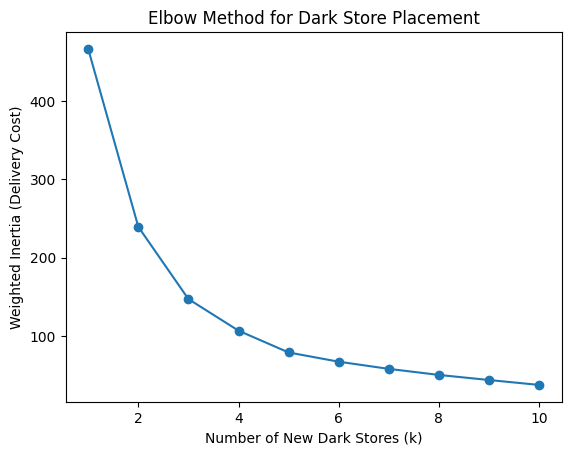

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(K_RANGE, inertia, marker="o")
plt.xlabel("Number of New Dark Stores (k)")
plt.ylabel("Weighted Inertia (Delivery Cost)")
plt.title("Elbow Method for Dark Store Placement")
plt.show()


In [43]:
# Pick the point where:
# Inertia reduction slows down
# Usually 3–5 for Pune-scale cities

# Here -> 4

In [44]:
OPTIMAL_K = 4

kmeans = KMeans(
    n_clusters=OPTIMAL_K,
    random_state=42,
    n_init=10
)

kmeans.fit(X, sample_weight=weights)

new_store_centers = kmeans.cluster_centers_

new_stores_df = pd.DataFrame(
    new_store_centers,
    columns=["store_latitude", "store_longitude"]
)

new_stores_df["store_type"] = "New (Cost Optimized)"

In [45]:
new_store_centers

array([[18.66324927, 74.02098939],
       [18.59149119, 73.87885127],
       [18.68614963, 73.87397397],
       [18.6187843 , 73.96205385]])

In [46]:
new_stores_df

,store_latitude,store_longitude,store_type
0,18.663249,74.020989,New (Cost Optimized)
1,18.591491,73.878851,New (Cost Optimized)
2,18.686150,73.873974,New (Cost Optimized)
3,18.618784,73.962054,New (Cost Optimized)


## Simulate Cost Reduction

In [47]:
old_stores = (
    df.groupby("store_id")
    .agg(
        store_latitude=("Restaurant_latitude", "first"),
        store_longitude=("Restaurant_longitude", "first")
    )
    .reset_index(drop=True)
)

all_stores = pd.concat(
    [old_stores, new_stores_df[["store_latitude", "store_longitude"]]],
    ignore_index=True
)

In [48]:
all_stores

,store_latitude,store_longitude
0,18.514210,73.838429
1,18.516216,73.842527
2,18.520016,73.830547
3,18.530963,73.828972
4,18.533811,73.899315
5,18.534080,73.898520
6,18.536562,73.896485
7,18.536718,73.830327
8,18.539299,73.897902
9,18.543626,73.905101


In [49]:
import numpy as np

def haversine_customer_store(customer_coords, store_coords):
    """
    customer_coords: (N, 2) -> [lat, lon]
    store_coords: (M, 2) -> [lat, lon]
    returns: (N, M) distance matrix in KM
    """
    R = 6371  # Earth radius in km

    cust_lat = np.radians(customer_coords[:, 0])[:, None]
    cust_lon = np.radians(customer_coords[:, 1])[:, None]

    store_lat = np.radians(store_coords[:, 0])[None, :]
    store_lon = np.radians(store_coords[:, 1])[None, :]

    dlat = store_lat - cust_lat
    dlon = store_lon - cust_lon

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(cust_lat) * np.cos(store_lat) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


In [51]:
customer_points = df[[
    "Delivery_location_latitude",
    "Delivery_location_longitude"
]].values

store_points = all_stores[[
    "store_latitude",
    "store_longitude"
]].values

# Haversine distance matrix (KM)
dist_matrix_km = haversine_customer_store(customer_points, store_points)

# Nearest store distance (KM)
nearest_store_dist = dist_matrix_km.min(axis=1)

# Optional: nearest store index
nearest_store_idx = dist_matrix_km.argmin(axis=1)

df["new_distance_km"] = nearest_store_dist
df["nearest_store_idx"] = nearest_store_idx


In [53]:
df

,ID,Delivery_person_ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,order_freq,Time_taken (min),traffic_weight,distance_km,delivery_cost,store_id,heat_weight,new_distance_km,nearest_store_idx
2,0x2784,PUNERES13DEL03,18.562450,73.916619,18.652450,74.006619,Medium,2,21,1.3,13.787860,35.848437,18.56245_73.916619,80,1.932352,20
7,0x689b,PUNERES20DEL01,18.592718,73.773572,18.702718,73.883572,Jam,2,40,2.0,16.849940,67.399760,18.592718_73.773572,80,2.101464,22
10,0x36b8,PUNERES19DEL02,18.563934,73.915367,18.643935,73.995367,Jam,3,36,2.0,12.256076,73.536459,18.563934_73.915367,120,3.449528,20
19,0x3c5e,PUNERES04DEL01,18.514210,73.838429,18.624210,73.948429,Low,1,12,1.0,16.853619,16.853619,18.51421_73.838429,40,1.557312,23
25,0x30c8,PUNERES19DEL02,18.563934,73.915367,18.693935,74.045367,Low,2,30,1.0,19.914687,39.829374,18.563934_73.915367,80,4.270421,20
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45503,0x7ab,PUNERES12DEL02,18.520016,73.830547,18.650016,73.960547,Jam,1,22,2.0,19.917038,39.834076,18.520016_73.830547,40,3.476434,23
45533,0x3d40,PUNERES18DEL01,18.593481,73.785901,18.703481,73.895901,Low,1,28,1.0,16.849904,16.849904,18.593481_73.785901,40,3.007973,22
45544,0x46b6,PUNERES03DEL01,18.554382,73.798206,18.594382,73.838206,High,1,28,1.6,6.128501,9.805602,18.554382_73.798206,40,4.295706,21
45549,0x7328,PUNERES08DEL01,18.534080,73.898520,18.604080,73.968520,Jam,2,47,2.0,10.725035,42.900139,18.53408_73.89852,80,1.771349,23


In [54]:
df["new_delivery_cost"] = (
    df["new_distance_km"]
    * df["traffic_weight"]
    * df["order_freq"]
)

In [55]:
df.shape

(3132, 17)

In [56]:
df

,ID,Delivery_person_ID,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Road_traffic_density,order_freq,Time_taken (min),traffic_weight,distance_km,delivery_cost,store_id,heat_weight,new_distance_km,nearest_store_idx,new_delivery_cost
2,0x2784,PUNERES13DEL03,18.562450,73.916619,18.652450,74.006619,Medium,2,21,1.3,13.787860,35.848437,18.56245_73.916619,80,1.932352,20,5.024115
7,0x689b,PUNERES20DEL01,18.592718,73.773572,18.702718,73.883572,Jam,2,40,2.0,16.849940,67.399760,18.592718_73.773572,80,2.101464,22,8.405855
10,0x36b8,PUNERES19DEL02,18.563934,73.915367,18.643935,73.995367,Jam,3,36,2.0,12.256076,73.536459,18.563934_73.915367,120,3.449528,20,20.697169
19,0x3c5e,PUNERES04DEL01,18.514210,73.838429,18.624210,73.948429,Low,1,12,1.0,16.853619,16.853619,18.51421_73.838429,40,1.557312,23,1.557312
25,0x30c8,PUNERES19DEL02,18.563934,73.915367,18.693935,74.045367,Low,2,30,1.0,19.914687,39.829374,18.563934_73.915367,80,4.270421,20,8.540843
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45503,0x7ab,PUNERES12DEL02,18.520016,73.830547,18.650016,73.960547,Jam,1,22,2.0,19.917038,39.834076,18.520016_73.830547,40,3.476434,23,6.952868
45533,0x3d40,PUNERES18DEL01,18.593481,73.785901,18.703481,73.895901,Low,1,28,1.0,16.849904,16.849904,18.593481_73.785901,40,3.007973,22,3.007973
45544,0x46b6,PUNERES03DEL01,18.554382,73.798206,18.594382,73.838206,High,1,28,1.6,6.128501,9.805602,18.554382_73.798206,40,4.295706,21,6.873130
45549,0x7328,PUNERES08DEL01,18.534080,73.898520,18.604080,73.968520,Jam,2,47,2.0,10.725035,42.900139,18.53408_73.89852,80,1.771349,23,7.085397


In [54]:
df.columns

Index(['ID', 'Delivery_person_ID', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Weather_conditions',
       'Road_traffic_density', 'order_freq', 'Time_taken (min)',
       'traffic_weight', 'weather_weight', 'distance_km', 'delivery_cost',
       'store_id', 'heat_weight', 'new_distance_km', 'new_delivery_cost'],
      dtype='object')

In [57]:
old_cost = df["delivery_cost"].sum()
new_cost = df["new_delivery_cost"].sum()

reduction_pct = ((old_cost - new_cost) / old_cost) * 100

print(f"Old Total Cost: {old_cost:.2f}")
print(f"New Total Cost: {new_cost:.2f}")
print(f"Cost Reduction: {reduction_pct:.2f}%")

Old Total Cost: 80744.37
New Total Cost: 22771.06
Cost Reduction: 71.80%


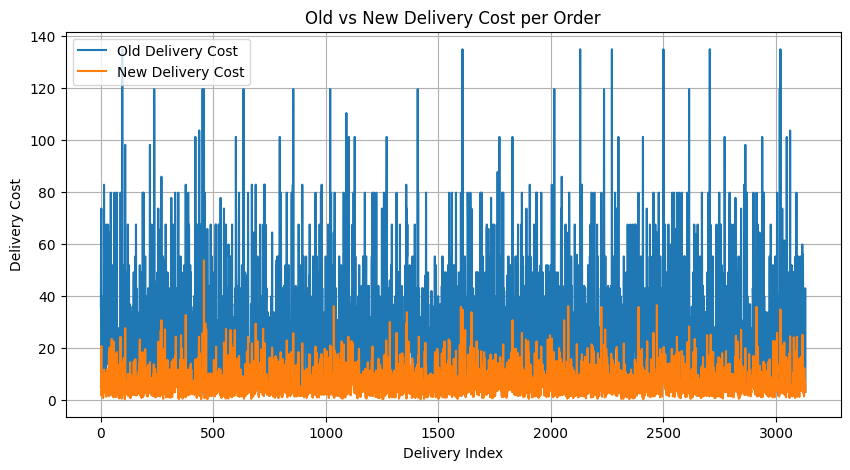

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(df["delivery_cost"].values, label="Old Delivery Cost")
plt.plot(df["new_delivery_cost"].values, label="New Delivery Cost")

plt.xlabel("Delivery Index")
plt.ylabel("Delivery Cost")
plt.title("Old vs New Delivery Cost per Order")
plt.legend()
plt.grid(True)

plt.show()


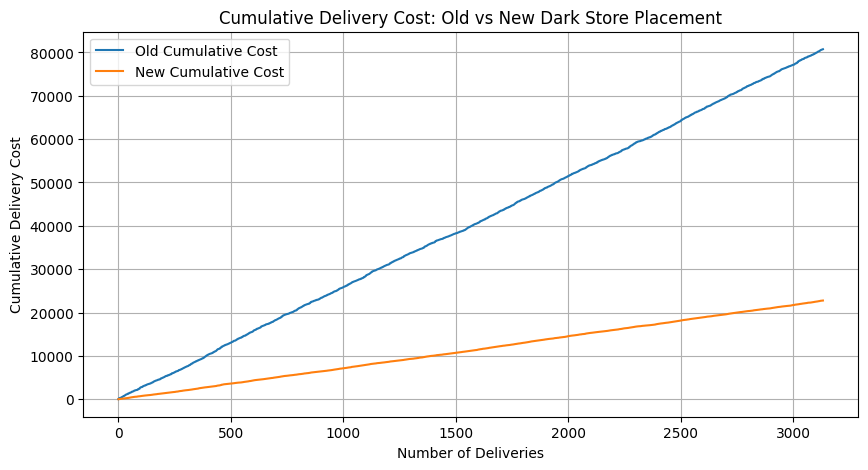

In [59]:
df_sorted = df.reset_index(drop=True)

df_sorted["old_cumulative_cost"] = df_sorted["delivery_cost"].cumsum()
df_sorted["new_cumulative_cost"] = df_sorted["new_delivery_cost"].cumsum()

plt.figure(figsize=(10, 5))

plt.plot(df_sorted["old_cumulative_cost"], label="Old Cumulative Cost")
plt.plot(df_sorted["new_cumulative_cost"], label="New Cumulative Cost")

plt.xlabel("Number of Deliveries")
plt.ylabel("Cumulative Delivery Cost")
plt.title("Cumulative Delivery Cost: Old vs New Dark Store Placement")
plt.legend()
plt.grid(True)

plt.show()


## Merge Redundant Stores

Haversine Distance Function (KM)

In [60]:
import numpy as np

def haversine_matrix(coords):
    """
    coords: numpy array of shape (n, 2) -> [lat, lon] in degrees
    returns: (n x n) distance matrix in KM
    """
    R = 6371  # Earth radius in km

    lat = np.radians(coords[:, 0])
    lon = np.radians(coords[:, 1])

    lat1 = lat[:, None]
    lat2 = lat[None, :]
    lon1 = lon[:, None]
    lon2 = lon[None, :]

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))
    return R * c


Assign Customers to Nearest Store (Haversine)

In [61]:
# Store coordinates
store_coords = all_stores[
    ["store_latitude", "store_longitude"]
].values

# Customer coordinates
customer_coords = df[
    ["Delivery_location_latitude", "Delivery_location_longitude"]
].values

# Combine to compute distances efficiently
combined_coords = np.vstack([customer_coords, store_coords])

# Full distance matrix (Haversine)
dist_all = haversine_matrix(combined_coords)

# Extract customer → store distances
cust_store_dist = dist_all[
    :len(customer_coords),
    len(customer_coords):
]

df["assigned_store_idx"] = cust_store_dist.argmin(axis=1)
df["assigned_distance_km"] = cust_store_dist.min(axis=1)


Compute Cost Contribution per Store

In [62]:
df["assigned_delivery_cost"] = (
    df["assigned_distance_km"]
    * df["traffic_weight"]
    * df["order_freq"]
)

store_usage = (
    df.groupby("assigned_store_idx")
    .agg(
        total_cost=("assigned_delivery_cost", "sum"),
        total_orders=("order_freq", "sum")
    )
    .reset_index()
)


In [63]:
store_distance_km = haversine_matrix(store_coords)

Identify Redundant Store Pairs

In [64]:
REDUNDANCY_THRESHOLD_KM = 2.0

redundant_pairs = np.where(
    (store_distance_km < REDUNDANCY_THRESHOLD_KM) &
    (store_distance_km > 0)
)



Decide Which Store to Remove (CORE LOGIC)

In [65]:
stores_to_remove = set()

for i, j in zip(*redundant_pairs):
    if i in stores_to_remove or j in stores_to_remove:
        continue

    cost_i = store_usage.loc[
        store_usage["assigned_store_idx"] == i, "total_cost"
    ].sum()

    cost_j = store_usage.loc[
        store_usage["assigned_store_idx"] == j, "total_cost"
    ].sum()

    # Remove lower-impact store
    if cost_i <= cost_j:
        stores_to_remove.add(i)
    else:
        stores_to_remove.add(j)


In [66]:
optimized_stores = all_stores.drop(
    index=list(stores_to_remove)
).reset_index(drop=True)

removed_stores = all_stores.loc[
    list(stores_to_remove)
].reset_index(drop=True)


In [67]:
print("Original stores:", len(all_stores))
print("Removed redundant stores:", len(removed_stores))
print("Final optimized stores:", len(optimized_stores))


Original stores: 24
Removed redundant stores: 12
Final optimized stores: 12


## visualize the stores

In [68]:
import folium
from folium.plugins import HeatMap

In [69]:
center_lat = df["Delivery_location_latitude"].mean()
center_lon = df["Delivery_location_longitude"].mean()

m = folium.Map(
    location=[center_lat, center_lon],
    zoom_start=12,
    tiles="cartodbpositron"
)


In [70]:
# Scale demand for better visualization
df["heat_weight"] = df["order_freq"] * 40

heatmap_data = df[
    ["Delivery_location_latitude",
     "Delivery_location_longitude",
     "heat_weight"]
].values.tolist()

HeatMap(
    heatmap_data,
    radius=30,
    blur=40,
    min_opacity=0.6
).add_to(m)


In [71]:
for _, row in optimized_stores.iterrows():
    folium.Marker(
        location=[row["store_latitude"], row["store_longitude"]],
        icon=folium.Icon(
            icon="check-circle",
            prefix="fa",
            color="green"
        ),
        popup="KEPT Dark Store"
    ).add_to(m)


In [72]:
for _, row in removed_stores.iterrows():
    folium.Marker(
        location=[row["store_latitude"], row["store_longitude"]],
        icon=folium.Icon(
            icon="times-circle",
            prefix="fa",
            color="red"
        ),
        popup="REMOVED Dark Store"
    ).add_to(m)


In [73]:
m

In [74]:
m.save("final_store_optimization_with_heatmap.html")